# Pembangunan Model XGBoost untuk Klasifikasi Diabetes

Notebook ini disusun mengikuti pola `Pembangunan_Model_Preprocessing.ipynb`, namun difokuskan khusus untuk model XGBoost pada dataset diabetes.

## Tujuan
- Membuat alur preprocessing otomatis
- Melatih dan menuning model XGBoost
- Mengevaluasi performa model dengan metrik klasifikasi
- Menampilkan feature importance dan SHAP
- Menyimpan model terbaik untuk kebutuhan deployment


In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")


## 8. Import Required Libraries

Notebook ini menggunakan pustaka utama berikut:
- `pandas`, `numpy`
- `scikit-learn`
- `xgboost`
- `matplotlib`, `seaborn`
- `joblib`
- `shap` untuk interpretasi model

Jika package belum ada, jalankan:
`pip install xgboost shap joblib`


In [2]:
data_path = os.path.join("dataset", "diabetes_dataset.csv")
df = pd.read_csv(data_path)

print("Shape dataset:", df.shape)
display(df.head())
print("\nInfo dataset:")
df.info()
print("\nMissing values:")
display(df.isnull().sum().to_frame(name="missing_values"))
print("\nStatistik deskriptif:")
display(df.describe(include="all").transpose())
print("\nDistribusi target:")
display(df["diabetes"].value_counts().to_frame(name="count"))


Shape dataset: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Missing values:


,missing_values
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0



Statistik deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0



Distribusi target:


,count
diabetes,
0,91500
1,8500


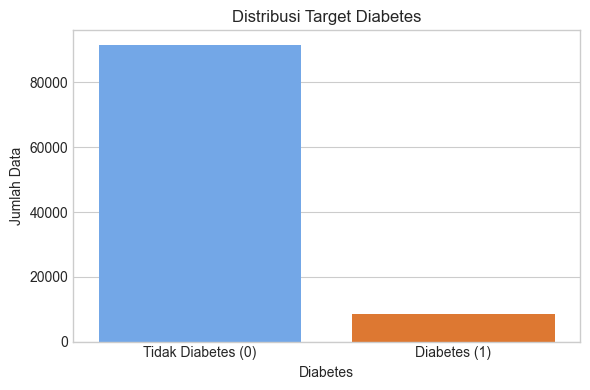

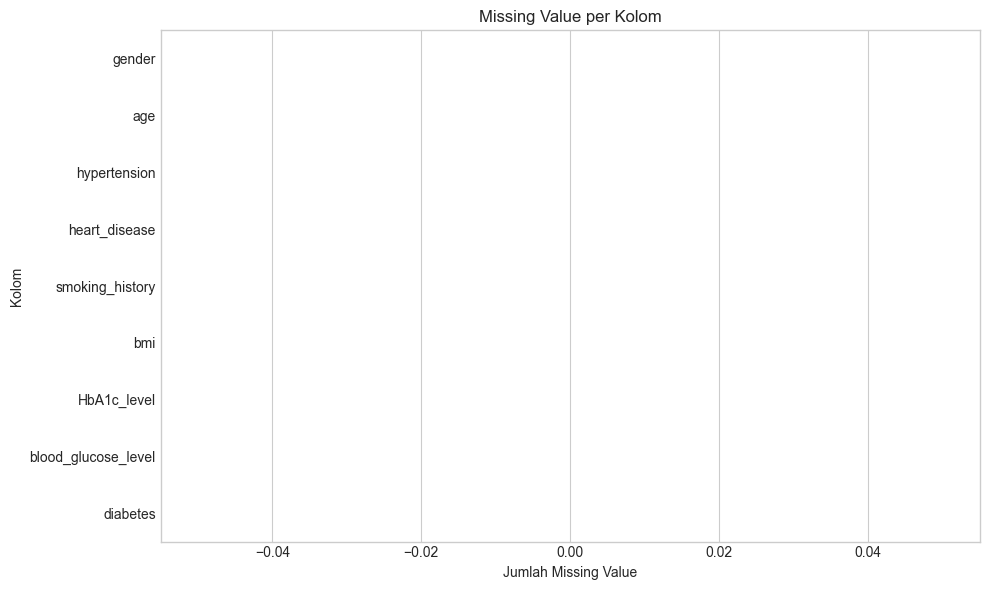

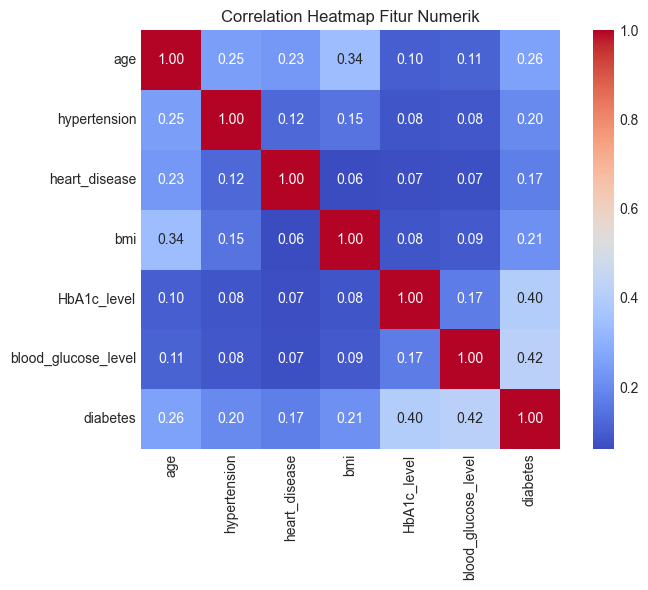

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diabetes", palette=["#60a5fa", "#f97316"])
plt.title("Distribusi Target Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Jumlah Data")
plt.xticks([0, 1], ["Tidak Diabetes (0)", "Diabetes (1)"])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
missing_counts = df.isnull().sum().sort_values(ascending=False)
sns.barplot(x=missing_counts.values, y=missing_counts.index, palette="Blues_r")
plt.title("Missing Value per Kolom")
plt.xlabel("Jumlah Missing Value")
plt.ylabel("Kolom")
plt.tight_layout()
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap Fitur Numerik")
plt.tight_layout()
plt.show()


## Visualisasi 2D - Eksplorasi Data Awal

Bagian ini menambahkan visual 2D agar data awal lebih mudah dibaca sebelum masuk ke tahap preprocessing dan training.


## 9. Load Dataset dan Inspeksi Data Awal

Dataset diabetes dibaca dari file CSV pada folder `dataset/`.

Pada tahap ini notebook menampilkan:
- `head()` untuk melihat data awal
- `shape` untuk mengetahui ukuran dataset
- `info()` untuk tipe data dan missing value
- `describe()` untuk statistik ringkas
- `isnull().sum()` dan `value_counts()` untuk inspeksi target


In [4]:
target_column = "diabetes"
X = df.drop(columns=[target_column])
y = df[target_column]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [column for column in X.columns if column not in categorical_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Categorical features: ['gender', 'smoking_history']


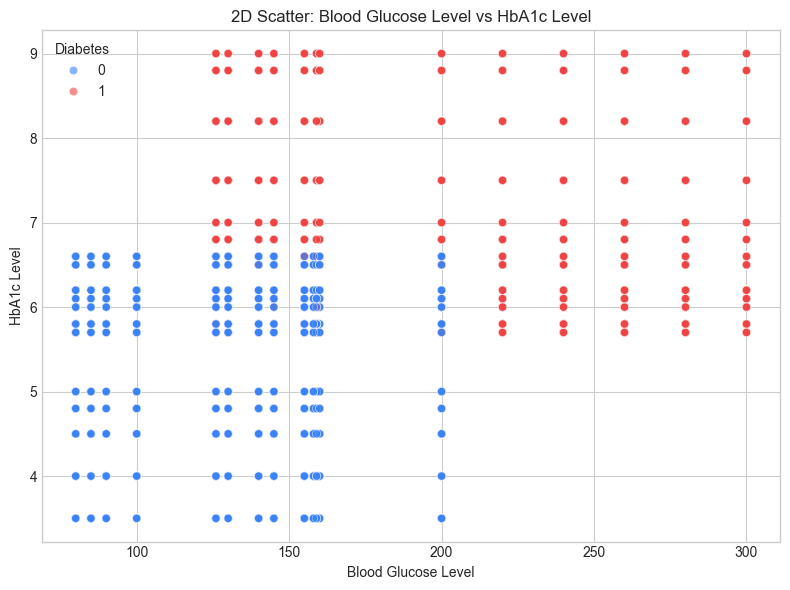

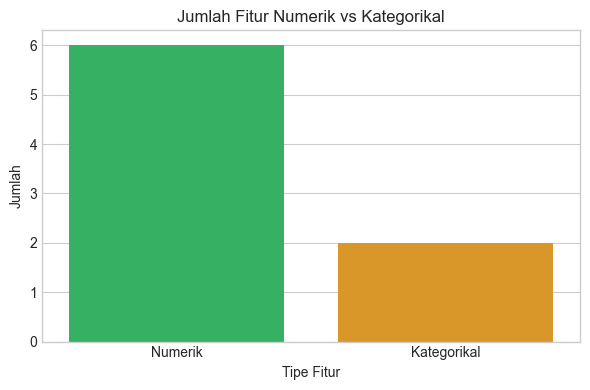

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="blood_glucose_level",
    y="HbA1c_level",
    hue="diabetes",
    palette={0: "#3b82f6", 1: "#ef4444"},
    alpha=0.6,
)
plt.title("2D Scatter: Blood Glucose Level vs HbA1c Level")
plt.xlabel("Blood Glucose Level")
plt.ylabel("HbA1c Level")
plt.legend(title="Diabetes")
plt.tight_layout()
plt.show()

feature_kind = pd.DataFrame({
    "Type": ["Numerik", "Kategorikal"],
    "Count": [len(numeric_features), len(categorical_features)],
})
plt.figure(figsize=(6, 4))
sns.barplot(data=feature_kind, x="Type", y="Count", palette=["#22c55e", "#f59e0b"])
plt.title("Jumlah Fitur Numerik vs Kategorikal")
plt.xlabel("Tipe Fitur")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()


## Visualisasi 2D - Hubungan Fitur dan Target

Visual berikut membantu melihat pola antar fitur sebelum model dilatih.


## 10. Preprocessing Data

Tahap preprocessing pada notebook ini mencakup:
- imputasi nilai hilang untuk fitur numerik dan kategorikal
- encoding fitur kategorikal dengan `OneHotEncoder`
- scaling fitur numerik menggunakan `StandardScaler`

Walaupun scaling tidak wajib untuk XGBoost, pipeline ini tetap disiapkan agar notebook fleksibel jika digunakan bersama metode lain.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("CV folds:", cv.get_n_splits())


Train shape: (80000, 8)
Test shape: (20000, 8)
CV folds: 5


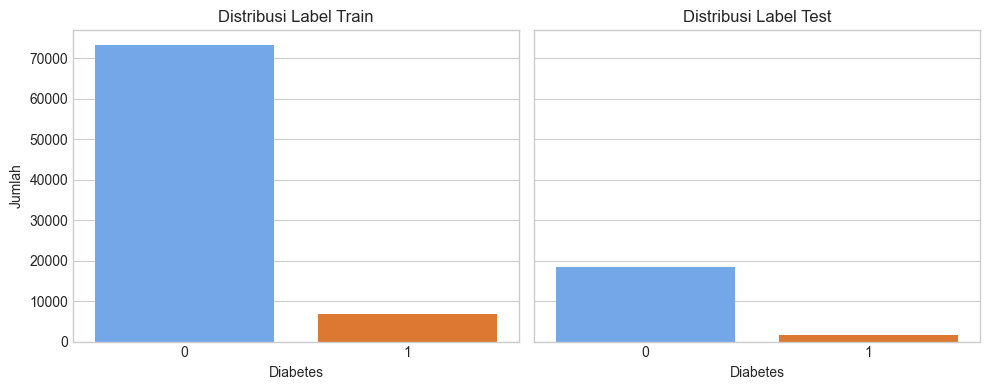

In [7]:
train_dist = y_train.value_counts().sort_index()
test_dist = y_test.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
sns.barplot(x=train_dist.index.astype(str), y=train_dist.values, ax=axes[0], palette=["#60a5fa", "#f97316"])
axes[0].set_title("Distribusi Label Train")
axes[0].set_xlabel("Diabetes")
axes[0].set_ylabel("Jumlah")

sns.barplot(x=test_dist.index.astype(str), y=test_dist.values, ax=axes[1], palette=["#60a5fa", "#f97316"])
axes[1].set_title("Distribusi Label Test")
axes[1].set_xlabel("Diabetes")
axes[1].set_ylabel("Jumlah")

plt.tight_layout()
plt.show()


## Visualisasi 2D - Distribusi Train/Test

Visual ini menunjukkan keseimbangan label pada data train dan test setelah stratified split.


## 11. Train/Test Split & Cross-Validation Setup

Dataset dibagi menggunakan `train_test_split` dengan `stratify=y` agar distribusi kelas tetap seimbang.

Untuk validasi silang digunakan `StratifiedKFold` sehingga setiap fold tetap mempertahankan proporsi label diabetes.


In [8]:
param_distributions = {
    "model__n_estimators": [150, 200, 250, 300],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__reg_lambda": [1, 2, 5],
}

base_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist",
            ),
        ),
    ]
)

random_search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)
best_params = random_search.best_params_
print("Best Params:")
print(best_params)
print("Best CV Score:", round(random_search.best_score_, 4))

# Siapkan data hasil preprocessing untuk XGBoost native API
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out().tolist()
X_train_pre_df = pd.DataFrame(X_train_pre, columns=feature_names)
X_test_pre_df = pd.DataFrame(X_test_pre, columns=feature_names)

dtrain = xgb.DMatrix(X_train_pre_df, label=y_train, feature_names=feature_names)

cv_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": best_params["model__max_depth"],
    "eta": best_params["model__learning_rate"],
    "subsample": best_params["model__subsample"],
    "colsample_bytree": best_params["model__colsample_bytree"],
    "lambda": best_params["model__reg_lambda"],
    "seed": 42,
}

cv_results = xgb.cv(
    params=cv_params,
    dtrain=dtrain,
    num_boost_round=500,
    nfold=5,
    stratified=True,
    metrics="logloss",
    early_stopping_rounds=20,
    seed=42,
    as_pandas=True,
    verbose_eval=False,
)

best_iteration = len(cv_results)
print("Best iteration from xgb.cv:", best_iteration)

clean_params = {
    "n_estimators": best_iteration,
    "max_depth": best_params["model__max_depth"],
    "learning_rate": best_params["model__learning_rate"],
    "subsample": best_params["model__subsample"],
    "colsample_bytree": best_params["model__colsample_bytree"],
    "reg_lambda": best_params["model__reg_lambda"],
}

final_model = XGBClassifier(
    **clean_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

final_model.fit(
    X_train_pre_df,
    y_train,
    eval_set=[(X_test_pre_df, y_test)],
    verbose=False,
)

print("Final model selesai dilatih.")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params:
{'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Best CV Score: 0.8066
Best iteration from xgb.cv: 199
Final model selesai dilatih.


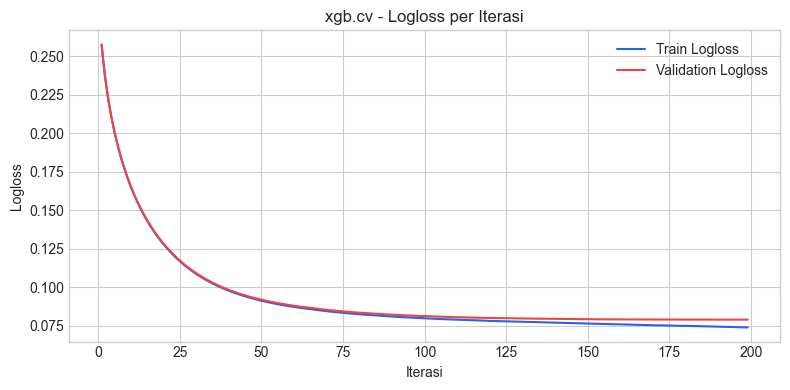

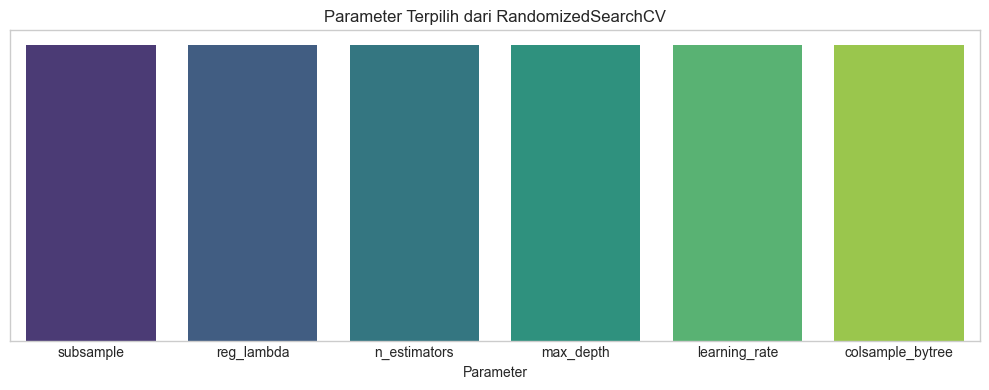

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(cv_results.index + 1, cv_results["train-logloss-mean"], label="Train Logloss", color="#2563eb")
plt.plot(cv_results.index + 1, cv_results["test-logloss-mean"], label="Validation Logloss", color="#ef4444")
plt.title("xgb.cv - Logloss per Iterasi")
plt.xlabel("Iterasi")
plt.ylabel("Logloss")
plt.legend()
plt.tight_layout()
plt.show()

best_param_names = [key.replace("model__", "") for key in best_params.keys()]
best_param_values = list(best_params.values())
plt.figure(figsize=(10, 4))
sns.barplot(x=best_param_names, y=[1] * len(best_param_names), palette="viridis")
plt.title("Parameter Terpilih dari RandomizedSearchCV")
plt.xlabel("Parameter")
plt.yticks([])
plt.tight_layout()
plt.show()


## Visualisasi 2D - Hasil Tuning dan Cross-Validation

Selain memilih parameter terbaik, notebook juga menampilkan pola hasil cross-validation agar performa tuning lebih mudah dijelaskan.


## 12. Train Model XGBoost, Hyperparameter Tuning, dan Cross-Validation

Pada tahap ini dilakukan:
- `RandomizedSearchCV` untuk mencari kombinasi parameter terbaik
- `xgb.cv` untuk validasi silang berbasis XGBoost
- training final model menggunakan parameter terbaik

Model akhir akan dipakai untuk evaluasi, interpretasi, dan penyimpanan.


Accuracy: 0.9720
Precision: 0.9742
Recall: 0.6894
F1-score: 0.8074
ROC AUC: 0.9799

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.97      0.69      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.97      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



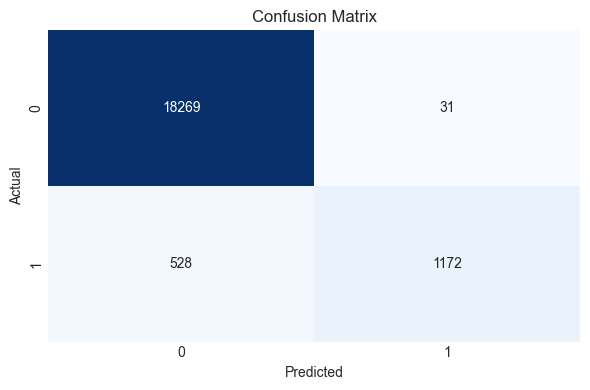

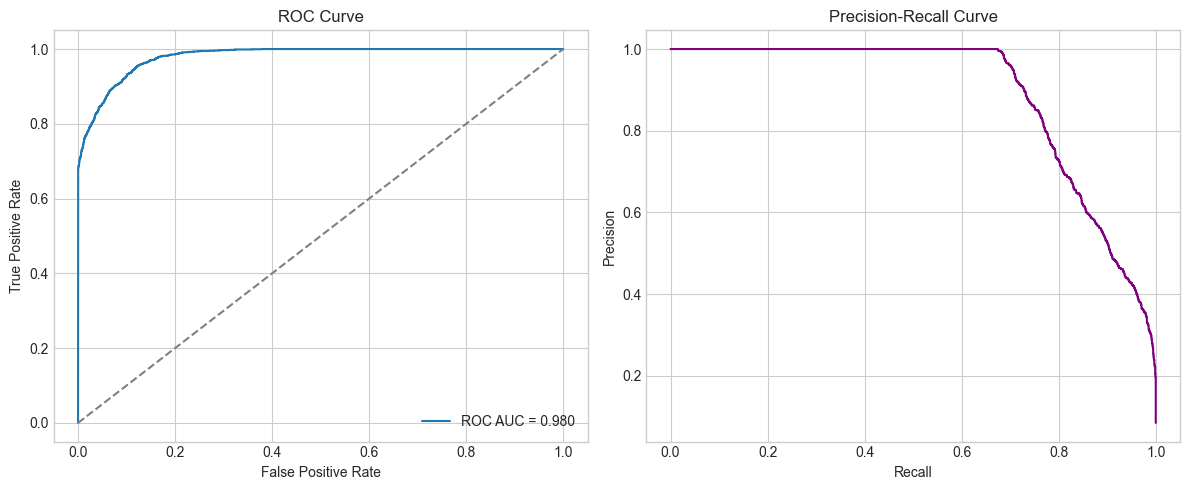

In [10]:
y_pred = final_model.predict(X_test_pre_df)
y_proba = final_model.predict_proba(X_test_pre_df)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, color="purple")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
plt.tight_layout()
plt.show()


## 13. Evaluasi Model dan Visualisasi

Di bagian ini model final dievaluasi menggunakan:
- Accuracy
- Precision
- Recall
- F1-score
- ROC AUC
- Confusion matrix

Selain itu ditampilkan grafik ROC curve dan Precision-Recall curve agar performa model lebih mudah dijelaskan secara visual.


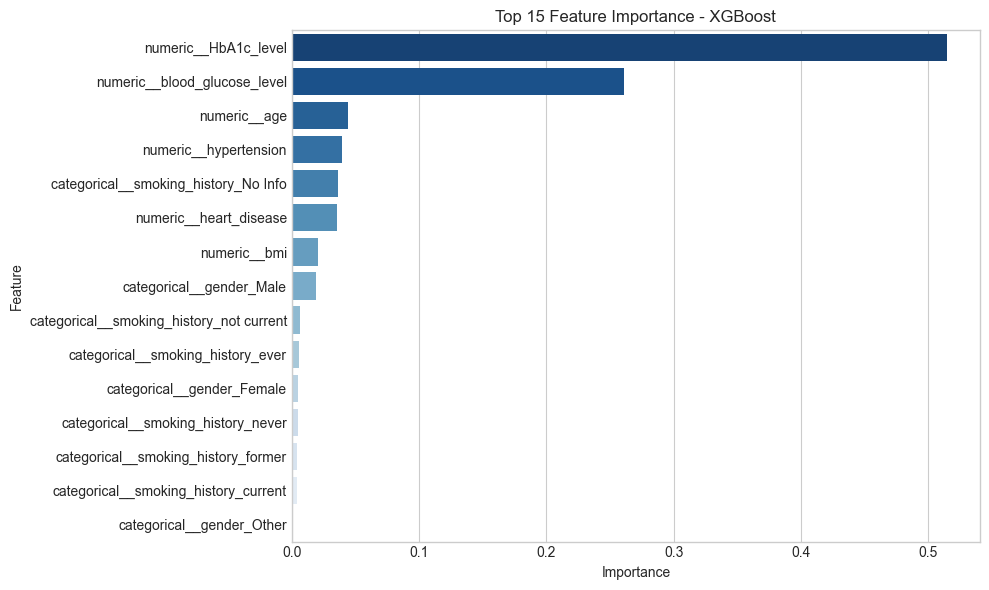

SHAP belum terinstall, lewati visualisasi SHAP.


In [11]:
# Feature importance
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature", palette="Blues_r")
plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# SHAP explanation
if shap_available:
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test_pre_df)
    shap.summary_plot(shap_values, X_test_pre_df, show=False)
    plt.tight_layout()
    plt.show()
else:
    print("SHAP belum terinstall, lewati visualisasi SHAP.")


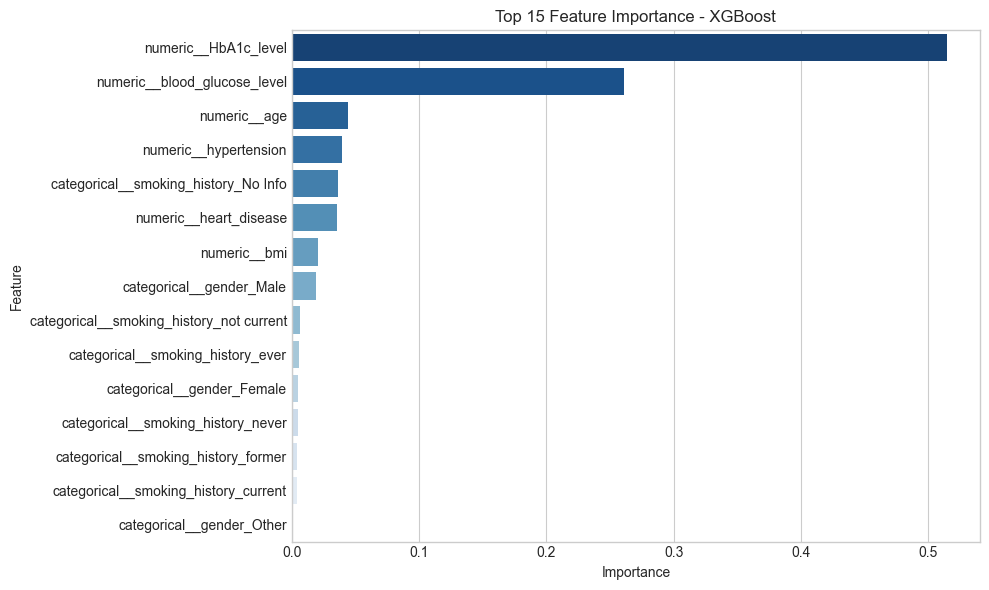

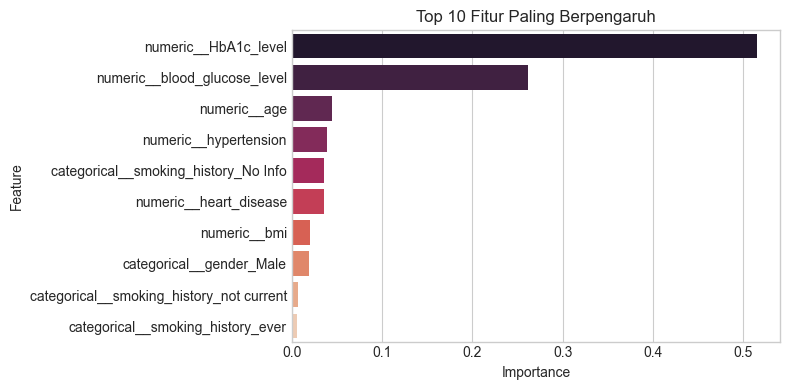

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature", palette="Blues_r")
plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importance.head(10), x="importance", y="feature", palette="rocket")
plt.title("Top 10 Fitur Paling Berpengaruh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Visualisasi 2D - Feature Importance dan SHAP

Bagian interpretasi model dibuat lebih visual agar hasil analisis mudah dijelaskan saat presentasi.


## 14. Feature Importance dan SHAP

Bagian ini digunakan untuk menjelaskan fitur mana yang paling berpengaruh pada prediksi diabetes.

- `xgb.plot_importance()` dipakai untuk melihat kontribusi fitur berdasarkan gain atau weight.
- `shap.TreeExplainer()` dipakai untuk interpretasi lokal dan global.

Jika `shap` belum tersedia di environment, jalankan:
`pip install shap`


In [13]:
# Simpan bundle model terbaik
os.makedirs("models", exist_ok=True)
model_bundle = {
    "preprocessor": preprocessor,
    "model": final_model,
    "best_params": best_params,
    "best_cv_iteration": best_iteration,
    "feature_names": feature_names,
}
joblib.dump(model_bundle, "models/diabetes_xgb_model.joblib")

# Muat kembali model untuk memastikan artefak valid
loaded_bundle = joblib.load("models/diabetes_xgb_model.joblib")
print("Model tersimpan dan berhasil dimuat kembali.")
print("Best params:", loaded_bundle["best_params"])


Model tersimpan dan berhasil dimuat kembali.
Best params: {'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


## 15. Simpan dan Muat Model

Model terbaik dapat disimpan menggunakan `joblib.dump()` agar bisa dipakai kembali pada aplikasi Streamlit atau proses inference lain.

Notebook ini menyimpan dua artefak penting:
- `models/diabetes_xgb_model.joblib` untuk model terlatih
- objek `preprocessor` untuk memastikan fitur inference diproses dengan cara yang sama


In [14]:
def preprocess_and_predict(input_df, fitted_preprocessor, fitted_model):
    """Lakukan preprocessing lalu inference untuk satu sampel atau batch."""
    transformed = fitted_preprocessor.transform(input_df)
    prediction = fitted_model.predict(transformed)
    probability = fitted_model.predict_proba(transformed)[:, 1]
    return prediction, probability

# Contoh single sample
sample_input = pd.DataFrame([
    {
        "gender": "Female",
        "age": 45,
        "hypertension": 0,
        "heart_disease": 0,
        "smoking_history": "never",
        "bmi": 27.3,
        "HbA1c_level": 5.8,
        "blood_glucose_level": 130,
    }
])

sample_prediction, sample_probability = preprocess_and_predict(sample_input, preprocessor, final_model)
print("Prediksi sample:", sample_prediction[0])
print("Probabilitas diabetes:", round(float(sample_probability[0]), 4))


Prediksi sample: 0
Probabilitas diabetes: 0.0406


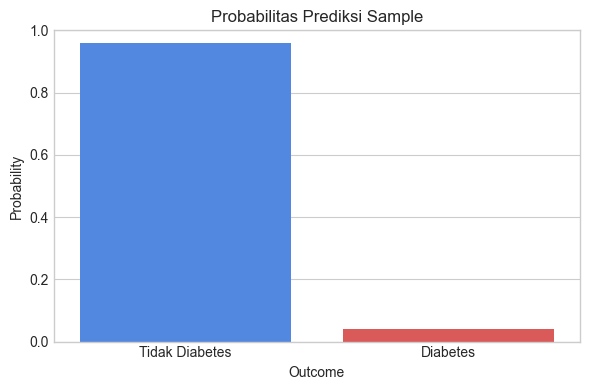

In [15]:
sample_chart = pd.DataFrame({
    "Outcome": ["Tidak Diabetes", "Diabetes"],
    "Probability": [1 - float(sample_probability[0]), float(sample_probability[0])],
})

plt.figure(figsize=(6, 4))
sns.barplot(data=sample_chart, x="Outcome", y="Probability", palette=["#3b82f6", "#ef4444"])
plt.title("Probabilitas Prediksi Sample")
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Visualisasi 2D - Contoh Inference

Contoh inference ditampilkan agar alur penggunaan model akhir terlihat jelas dan siap dipakai di aplikasi.


## 16. Kesimpulan

Notebook ini menunjukkan alur pembangunan model XGBoost untuk klasifikasi diabetes, mulai dari inspeksi data, preprocessing otomatis, tuning hyperparameter, validasi silang, evaluasi model, interpretasi fitur, hingga penyimpanan model terbaik.

Hasil akhir yang disimpan adalah model dengan performa terbaik untuk digunakan kembali pada proses inference atau integrasi ke aplikasi Streamlit.
